In [66]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
COLLOCATE_DIR = ROOT / "outputs" / "gulf_stream_cyclonic" / "collocate_pace"

In [67]:
rows = []
for polarity in ("cyclone", "anticyclone"):
    for fp in sorted((COLLOCATE_DIR / polarity).glob("eddy_*_rrs.parquet")):
        df = pd.read_parquet(fp, columns=["track_id", "date"])
        tid = df["track_id"].iloc[0]
        n_dates = df["date"].nunique()
        rows.append({"track_id": tid, "polarity": polarity, "n_dates": n_dates})

eddy_dates = pd.DataFrame(rows)
print(f"{len(eddy_dates)} eddies, {eddy_dates['n_dates'].sum()} total eddy-date instances")
eddy_dates.groupby("polarity")["n_dates"].describe().round(1)

76 eddies, 822 total eddy-date instances


,count,mean,std,min,25%,50%,75%,max
polarity,,,,,,,,
anticyclone,34.0,9.1,5.9,1.0,5.0,7.0,10.0,28.0
cyclone,42.0,12.2,9.0,1.0,5.2,11.5,14.8,35.0


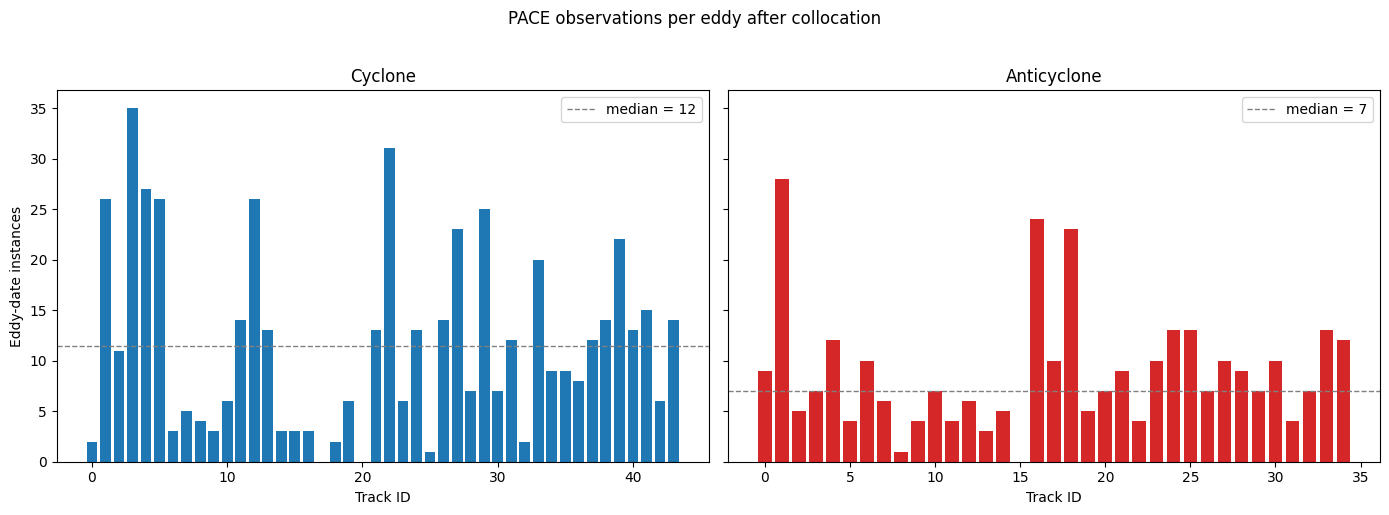

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (pol, color) in zip(axes, [("cyclone", "tab:blue"), ("anticyclone", "tab:red")]):
    sub = eddy_dates[eddy_dates["polarity"] == pol].sort_values("track_id")
    ax.bar(sub["track_id"].values, sub["n_dates"].values, color=color)
    ax.axhline(sub["n_dates"].median(), color="gray", ls="--", lw=1,
               label=f"median = {sub['n_dates'].median():.0f}")
    ax.set_xlabel("Track ID")
    ax.set_title(pol.capitalize())
    ax.legend()

axes[0].set_ylabel("Eddy-date instances")
fig.suptitle("PACE observations per eddy after collocation", y=1.02)
fig.tight_layout()